In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation

In [2]:
fl = gym.make(
    'FrozenLake-v1',
    desc=None,
    map_name="4x4",
    is_slippery=True,
    success_rate=1.0/3.0,
    reward_schedule=(1, 0, 0),
    render_mode = 'rgb_array',
)

In [3]:
action_dict = {
    'left': 0, 'down': 1, 'right': 2, 'up': 3,
}

In [4]:
n_states = 16
n_actions = 4
Q_table = np.zeros((n_states, n_actions)) # states X actions

New Q(S, A) = Old Q(S, A) + Learning_Rate * [Reward + Discount_Factor * Best_Q_Value_in_New_State - Old Q(S, A)]

In [5]:
# Init learning param
learning_rate = 0.8
discount_factor = 0.6

In [6]:
def compute_q (
        old_q, 
        best_q_in_new_state, 
        reward,
        lr=learning_rate, 
        df=discount_factor,
):
    td_target = reward + df * best_q_in_new_state - old_q
    new_q = old_q + lr * td_target

    return new_q

In [7]:
def get_table_pos(obs, ncols=4):
    row = obs // ncols
    col = obs % ncols

    return row, col

In [8]:
def get_q(obs, table, ncols=4):
    row, col = get_table_pos(obs, ncols)

    return table[row, col]

In [9]:
def set_q(obs, action, q, table):
    table[obs, action] = q

In [10]:
def get_best_q(obs, table):
    return table[obs].max()

In [11]:
def choose_action(obs, q_table):
    q_values = q_table[obs, :]
    max_value = np.max(q_values)
    # Find all actions that have the maximum Q-value
    best_actions = np.where(q_values == max_value)[0]
    # Randomly choose among ties
    return np.random.choice(best_actions)

In [12]:
def learn(env, table, lr, df):
    # reset env
    obs, info = env.reset()
    q = get_q(obs, table)
    done = False
    # print("env init")

    # start random interactions with env
    frame_list = [env.render()]
    s = 0
    while not done:
        # print(f"start step {s}")
        # choose an action
        action = choose_action(obs, table)
        # interact
        obs_new, reward, done, trancated, info = env.step(action)
        # render and save env
        frame_list.append(env.render())
        
        # get some values
        best_q = get_best_q(obs_new, table)
        # get new q
        q = compute_q(q, best_q, reward, lr, df)
        # set new q
        set_q(obs, action, q, table)
        # swap obs
        obs = obs_new

        # update s
        s += 1

    return frame_list, reward

In [13]:
def show_animation(frames):
    def animate(i):
        im.set_array(frames[i])
        return [im]
        
    # Init a fig
    fig = plt.figure(figsize=(6, 4))
    plt.axis('off')
    im = plt.imshow(frames[0])

    # Add frames into animation
    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=1)

    return HTML(anim.to_jshtml())

In [32]:
learning_res = []
for i in range(500):
    res, r = learn(fl, Q_table, learning_rate, discount_factor)
    learning_res.append(
        [res, r, Q_table.copy()]
    )
    if i % 100 == 0:
        print(f"Learning to {i} step")

Learning to 0 step
Learning to 100 step
Learning to 200 step
Learning to 300 step
Learning to 400 step


In [33]:
for idx, record in enumerate(learning_res):
    if record[1] == 1:
        print(idx)

23
37
39
65
87
119
144
159
197
200
233
249
320
322
323
340
351
352
378
391
401
413
418
426
429
433


In [34]:
target_id = 433

In [35]:
learning_res[target_id][2]

array([[0.0008518 , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.01606792, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.04346635],
       [0.        , 0.        , 0.02908675, 0.        ],
       [0.        , 0.06646981, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.04547648],
       [0.        , 0.        , 0.        , 0.8090953 ],
       [0.        , 0.        , 0.        , 0.        ]])

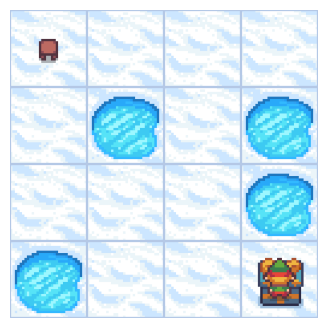

In [36]:
show_animation(learning_res[target_id][0])

In [96]:
obs, info = fl.reset()
q = get_q(obs, Q_table)

In [95]:
Q_table[15, 2] = 0.39473684
Q_table

array([[0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.39473684, 0.        ]])

In [97]:
frame_list = []

In [127]:
# interact
sim_action = action_dict['down']
obs, reward, done, trancated, info = fl.step(sim_action)
# render and save env
frm = fl.render()

In [128]:
obs, reward

(14, 0)

In [129]:
# get some values
best_q = get_best_q(obs, Q_table)
best_q

np.float64(0.0)

In [123]:
# get new q
q = compute_q(q, best_q, reward, learning_rate, discount_factor)
q

np.float64(0.0)

In [124]:
# set new q
set_q(obs, sim_action, q, Q_table)

In [125]:
Q_table

array([[0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.39473684, 0.        ]])

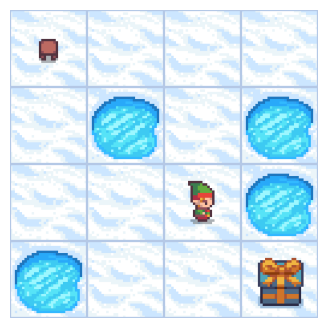

In [126]:
fig = plt.figure(figsize=(6, 4))
plt.axis('off')
im = plt.imshow(frm)

$r + \gamma \max_{a'} Q(s', a')$

$r + \gamma \max_{a'} Q_{\text{target}}(s', a')$